# Cell-1 — Imports, paths & helpers (FFT pipeline)

**What this cell does**
- Sets input/output folders (WSL paths).
- Provides dtype-safe I/O (`to_float32`/`from_float32`) and small preview helpers.
- Adds a GPU-optional 1-D FFT splitter: `fft1d_split(img, axis, cutoff_period_px, taper_pct, device)`.
  - **axis**: 0→operate along rows (good when stripes are *horizontal*), 1→operate along columns (good when stripes are *vertical*).
  - **cutoff_period_px**: period (in pixels) at the boundary; longer periods → **low-frequency**.
  - **taper_pct**: soft half-cosine transition around the cutoff to reduce ringing.
  - **device**: `"gpu"` if CuPy is available, else `"cpu"`.

**Model**
- Additive separation: `img = LF + HF`, created by multiplying the 1-D FFT by smooth **low-pass** and **high-pass** masks and inverse-transforming.

**Typical use**
- If stripes are mainly vertical → pick **axis=1** (operate along columns).  
  Start with `cutoff_period_px ≈ 32–128`, `taper_pct ≈ 10–20%`.
- If stripes are horizontal → pick **axis=0**.

**Potential pitfalls**
- Too small cutoff → LF eats details (80%).  
- Too large cutoff → HF still contains the stripe carrier (70%).  
- Noisy HF can show Gibbs if taper=0 (60%).


In [2]:
from __future__ import annotations
import re
from pathlib import Path
from typing import Dict, Any, Sequence, Tuple

import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

# ---- Optional GPU stack ----
try:
    import cupy as cp
    CUPY_OK = True
except Exception:
    CUPY_OK = False

# ---------------- Paths & shared state ----------------
DATA_DIR = Path("/home/askiran/data/Normalized_log/113")  # change if needed
OUT_DIR  = DATA_DIR / "freqsep_out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

STATE_FC: Dict[str, Any] = dict(
    device="gpu" if CUPY_OK else "cpu",
    last_path=None,
    last_img=None,
    last_axis=1,
    last_params=None,
    last_low=None,
    last_high=None,
    last_high_filtered=None,
    last_recon=None,
    last_meta=None
)

# ---------------- Small helpers ----------------
_num_re = re.compile(r"(\d+)")
def natural_key(s: str):
    return [int(t) if t.isdigit() else t.lower() for t in _num_re.split(s)]

def natural_sorted(paths: Sequence[Path]) -> list[Path]:
    return sorted(paths, key=lambda p: natural_key(str(p)))

def list_images(folder: Path) -> list[Path]:
    exts = (".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp")
    return natural_sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])

def to_float32(img: np.ndarray) -> Tuple[np.ndarray, Dict[str, Any]]:
    meta = {"dtype": img.dtype}
    if np.issubdtype(img.dtype, np.integer):
        info = np.iinfo(img.dtype)
        meta.update({"imin": info.min, "imax": info.max})
        x = (img.astype(np.float32) - info.min) / max(1.0, (info.max - info.min))
    elif np.issubdtype(img.dtype, np.floating):
        x = img.astype(np.float32, copy=False)
        meta.update({"imin": None, "imax": None})
    else:
        raise TypeError(f"Unsupported dtype: {img.dtype}")
    return x, meta

def from_float32(x: np.ndarray, meta: Dict[str, Any]) -> np.ndarray:
    dtype = meta["dtype"]
    if np.issubdtype(dtype, np.integer):
        imin, imax = meta["imin"], meta["imax"]
        y = np.clip(x, 0.0, 1.0) * (imax - imin) + imin
        return np.rint(y).astype(dtype)
    elif np.issubdtype(dtype, np.floating):
        return x.astype(dtype, copy=False)
    else:
        raise TypeError(f"Unsupported dtype: {dtype}")

def imread_gray(path: Path) -> Tuple[np.ndarray, Dict[str, Any]]:
    arr = iio.imread(path)
    if arr.ndim == 3:
        if arr.shape[-1] in (3,4):
            arr = (0.2126*arr[...,0] + 0.7152*arr[...,1] + 0.0722*arr[...,2]).astype(arr.dtype)
        else:
            arr = arr[...,0]
    x, meta = to_float32(arr)
    return x, meta

def imsave_roundtrip(path: Path, x_float: np.ndarray, meta: Dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    iio.imwrite(path, from_float32(x_float, meta))

def quick_stats(x: np.ndarray) -> Dict[str, float]:
    return dict(shape=tuple(x.shape),
                min=float(np.min(x)), p1=float(np.percentile(x,1)),
                mean=float(np.mean(x)), median=float(np.median(x)),
                p99=float(np.percentile(x,99)), max=float(np.max(x)),
                std=float(np.std(x)))

def show_side_by_side(a: np.ndarray, b: np.ndarray, titles=("A","B"), lock=True):
    if lock:
        both = np.concatenate([a.ravel(), b.ravel()])
        vmin, vmax = np.percentile(both, [1,99]).astype(float)
        scales = dict(vmin=vmin, vmax=vmax)
    else:
        scales = {}
    fig, axs = plt.subplots(1,2,figsize=(10,5))
    axs[0].imshow(a, cmap="gray", **scales); axs[0].set_title(titles[0]); axs[0].axis("off")
    axs[1].imshow(b, cmap="gray", **scales); axs[1].set_title(titles[1]); axs[1].axis("off")
    plt.show()

# ---------------- 1-D FFT split with soft cutoff ----------------
def _soft_lowpass_mask_backend(xp, freq, fc: float, taper_pct: float):
    """
    Half-cosine low-pass mask built on the same backend (NumPy/CuPy) as `freq`.
      - 1 below f1, 0 above f2, cosine ramp between.
    """
    a = float(max(0.0, min(0.9, taper_pct / 100.0)))
    f1 = float(fc * (1.0 - a))
    f2 = float(min(0.5, fc * (1.0 + a)))

    H = xp.ones_like(freq, dtype=xp.float32)
    H = H.astype(xp.float32, copy=False)

    H = H.copy()
    H[freq >= f2] = 0.0

    ramp = (freq > f1) & (freq < f2)
    if bool(xp.any(ramp)):
        # use xp.cos; np.pi is a plain float so it broadcasts fine
        t = (freq[ramp] - f1) / (max(1e-12, (f2 - f1)))
        H[ramp] = 0.5 * (1.0 + xp.cos(np.pi * t))
    return H

def fft1d_split(img_f32: np.ndarray, axis: int, cutoff_period_px: int, taper_pct: float=15.0, device: str="cpu"):
    """
    Split image into low/high frequency parts along one axis via rFFT.
    Returns (low, high) as float32 (NumPy arrays). Works on CPU or GPU.
    """
    axis = int(axis)
    use_gpu = (device == "gpu" and CUPY_OK)
    xp = cp if use_gpu else np

    y = xp.asarray(img_f32, dtype=xp.float32)
    N = y.shape[axis]
    cutoff_period_px = int(max(2, min(cutoff_period_px, max(2, N//2))))
    fc = 1.0 / float(cutoff_period_px)  # cycles per pixel, 0..0.5

    # rFFT along axis
    Y = xp.fft.rfft(y, axis=axis)
    freq = xp.fft.rfftfreq(N, d=1.0)  # same backend as Y

    # build soft low-pass on the same backend
    H_low = _soft_lowpass_mask_backend(xp, freq, fc=fc, taper_pct=taper_pct)

    # broadcast mask to the FFT axis
    shape = [1]*y.ndim
    shape[axis] = H_low.shape[0]
    H_low = H_low.reshape(shape)

    Y_low  = Y * H_low
    Y_high = Y - Y_low

    low  = xp.fft.irfft(Y_low,  n=N, axis=axis)
    high = xp.fft.irfft(Y_high, n=N, axis=axis)

    if use_gpu:
        low  = cp.asnumpy(low)
        high = cp.asnumpy(high)

    return np.asarray(low,  np.float32), np.asarray(high, np.float32)


print(f"CUPY_OK = {CUPY_OK}")


CUPY_OK = True


# Cell-2 — Pick an image & split (UI)

**What this cell does**
- Lets you choose one image from `DATA_DIR`.
- Splits into **LF** and **HF** along a chosen axis using a soft cutoff (1-D FFT).
- Shows *Original vs Low vs High*.

**Widgets**
- **Image**: file selector
- **Split axis**: 0 (operate along rows) / 1 (columns)
- **Cutoff period [px]**: boundary period; *bigger = more of the image goes to LF*
- **Taper [%]**: 0–30% is typical; prevents ringing
- **Device**: `"gpu"` if available

**Tuning**
- If stripes are vertical → set **Split axis=1** and try period 32–128, taper 10–20%.


In [1]:
from ipywidgets import Dropdown, IntSlider, FloatSlider, Button, HBox, VBox, HTML, Output

paths = list_images(DATA_DIR)
if not paths:
    raise RuntimeError(f"No images found in {DATA_DIR}")

img_dd   = Dropdown(options=[(p.name, p) for p in paths], description="Image:", layout={"width":"400px"})
axis_dd  = Dropdown(options=[("axis=0 (rows)",0), ("axis=1 (cols)",1)], value=1, description="Split axis:")
cutoff_sl = IntSlider(value=64, min=4, max=512, step=2, description="Cutoff period [px]:")
taper_sl = FloatSlider(value=15.0, min=0.0, max=50.0, step=1.0, description="Taper [%]:")
dev_dd   = Dropdown(options=["cpu"] + (["gpu"] if CUPY_OK else []), value=("gpu" if CUPY_OK else "cpu"), description="Device:")
run_bt   = Button(description="Split (FFT)", button_style="primary")
out2 = Output()

def _refresh_cutoff_range(*_):
    # Adjust the slider max to half the current length along axis
    p = img_dd.value
    x, _ = imread_gray(p)
    N = x.shape[int(axis_dd.value)]
    cutoff_sl.max = max(8, int(N//2))
    # keep value within bounds
    cutoff_sl.value = min(cutoff_sl.value, cutoff_sl.max)

def _run_split(_):
    with out2:
        out2.clear_output()
        p = img_dd.value
        img, meta = imread_gray(p)
        low, high = fft1d_split(img, axis=int(axis_dd.value),
                                cutoff_period_px=int(cutoff_sl.value),
                                taper_pct=float(taper_sl.value),
                                device=str(dev_dd.value))
        STATE_FC.update(last_path=p, last_img=img, last_axis=int(axis_dd.value),
                        last_params=dict(cutoff_px=int(cutoff_sl.value), taper=float(taper_sl.value),
                                         device=str(dev_dd.value)),
                        last_low=low, last_high=high, last_meta=meta)
        s = quick_stats(img)
        print(f"Loaded: {p.name} | shape={s['shape']} | mean={s['mean']:.4f} std={s['std']:.4f}")
        # visualize
        vmin, vmax = np.percentile(img, [1,99]).astype(float)
        fig, axs = plt.subplots(1,3,figsize=(15,5))
        axs[0].imshow(img,  cmap="gray", vmin=vmin, vmax=vmax); axs[0].set_title("Original"); axs[0].axis("off")
        axs[1].imshow(STATE_FC["last_low"],  cmap="gray", vmin=vmin, vmax=vmax); axs[1].set_title("Low-freq"); axs[1].axis("off")
        # HF is zero-meanish; auto-scale it
        axs[2].imshow(STATE_FC["last_high"], cmap="gray"); axs[2].set_title("High-freq"); axs[2].axis("off")
        plt.tight_layout(); plt.show()

for w in (img_dd, axis_dd):
    w.observe(_refresh_cutoff_range, names="value")
_refresh_cutoff_range()

run_bt.on_click(_run_split)
display(VBox([HBox([img_dd]), HBox([axis_dd, cutoff_sl, taper_sl, dev_dd, run_bt]), out2]))


NameError: name 'list_images' is not defined

# Cell-3 — Filter/smooth the **High-frequency** part

**What this cell does**
- Applies 1-D filtering to the **HF** image to suppress stripe-like carriers while preserving detail.
- Filters:
  - **mean** → uniform_filter (fast)
  - **median** → median_filter (robust)
  - **gaussian** → gaussian_filter (gentle)

**Widgets**
- **HF filter axis**: 0 or 1 (often **perpendicular** to the stripe orientation)
- **Filter type**: gaussian / median / mean
- **Window**: odd size along the chosen axis
- **Show diff**: show `(HF_filtered − HF)` to see what changed

**Tips**
- Vertical stripes → HF filter axis = 1 (along columns) *or* 0 (perpendicular) depending on how the stripe energy sits; try both quickly.


In [5]:
from ipywidgets import RadioButtons, Checkbox

assert STATE_FC.get("last_high") is not None, "Run Cell-2 first (split into LF/HF)."

# default HF filter axis: start with the same axis used in the split (easy to toggle)
hf_axis_dd = Dropdown(options=[("axis=0",0),("axis=1",1)], value=int(STATE_FC["last_axis"]), description="HF filter axis:")
ft_dd   = RadioButtons(options=["gaussian","median","mean"], value="gaussian", description="Filter:")
win_sl  = IntSlider(value=9, min=3, max=99, step=2, description="Window")
show_diff_cb = Checkbox(value=True, description="Show difference panel")

out3 = Output()

def smooth_1d(A: np.ndarray, axis: int, filter_type: str, win: int) -> np.ndarray:
    win = int(win)
    if win % 2 == 0: win += 1
    if axis == 0:
        size = (win, 1); sigma = (max(win/3.0, 1.0), 0.0)
    else:
        size = (1, win); sigma = (0.0, max(win/3.0, 1.0))
    if filter_type == "mean":
        B = ndi.uniform_filter(A, size=size, mode="nearest")
    elif filter_type == "median":
        B = ndi.median_filter(A, size=size, mode="nearest")
    elif filter_type == "gaussian":
        B = ndi.gaussian_filter(A, sigma=sigma, mode="nearest")
    else:
        raise ValueError("Unknown filter.")
    return B.astype(np.float32, copy=False)

def _run_hf_filter(*_):
    with out3:
        out3.clear_output()
        hf0 = STATE_FC["last_high"].astype(np.float32, copy=False)
        hf1 = smooth_1d(hf0, axis=int(hf_axis_dd.value), filter_type=str(ft_dd.value), win=int(win_sl.value))
        STATE_FC["last_high_filtered"] = hf1
        titles = ("HF (before)", "HF (filtered)")
        if show_diff_cb.value:
            fig, axs = plt.subplots(1,3,figsize=(15,5))
            axs[0].imshow(hf0, cmap="gray"); axs[0].set_title(titles[0]); axs[0].axis("off")
            axs[1].imshow(hf1, cmap="gray"); axs[1].set_title(titles[1]); axs[1].axis("off")
            axs[2].imshow(hf1 - hf0, cmap="gray"); axs[2].set_title("Filtered − HF"); axs[2].axis("off")
            plt.tight_layout(); plt.show()
        else:
            show_side_by_side(hf0, hf1, titles=titles, lock=False)

for w in (hf_axis_dd, ft_dd, win_sl, show_diff_cb):
    w.observe(_run_hf_filter, names="value")
display(VBox([HBox([hf_axis_dd, ft_dd, win_sl, show_diff_cb]), out3]))
_run_hf_filter()


# Cell-4 — Reconstruct corrected image + metrics (SSIM/PSNR/MSE)

**What this cell does**
- Reconstructs a corrected image as  
  \[
  I_{\text{corr}} = \text{LF} + \text{HF}_{\text{filtered}}
  \]
  (pure additive combination; LF/HF were energy-partitioned in FFT).
- Reports **SSIM**, **PSNR**, **MSE** vs original (for bookkeeping) and shows an **SSIM map**.

**Notes**
- If you only want to *inspect* components, you can save LF or HF independently.
- If outputs look “soft”, decrease window or switch HF filter to **median** with a smaller size.

**Failure points**
- If `last_high_filtered` missing → run Cell-3. (95%)


SSIM  : 0.363203
PSNR  : 26.321 dB
MSE   : 1.392251e-03
Range : [0.0000, 0.7725]  (data_range=0.7725)


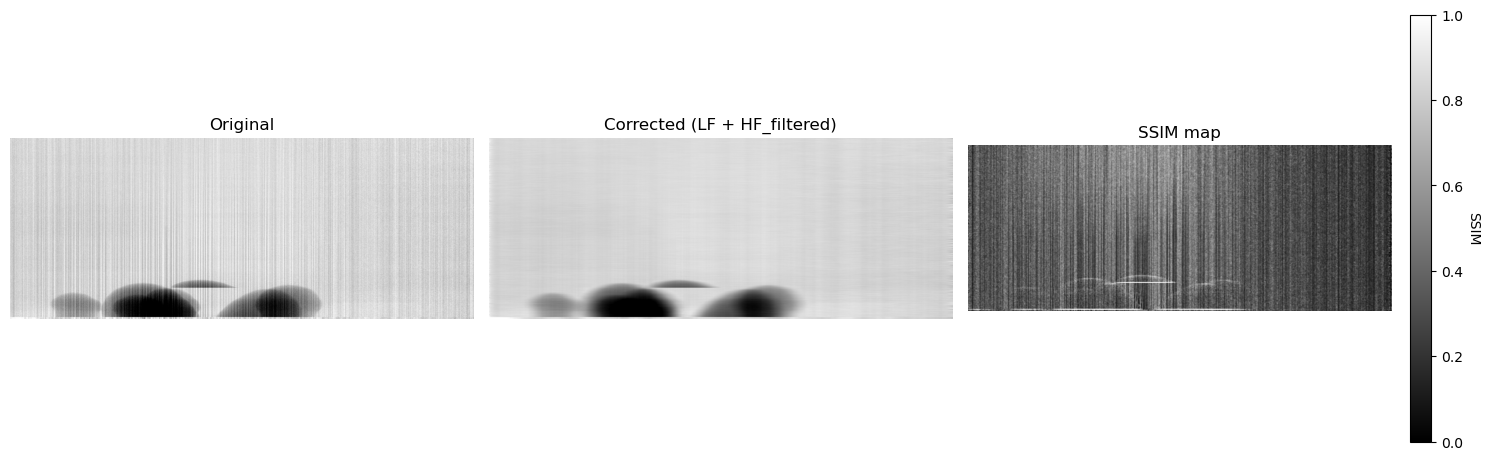

In [6]:
import numpy as np
import matplotlib.pyplot as plt

assert STATE_FC.get("last_high_filtered") is not None, "Run Cell-3 to filter the HF part."

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse

orig = STATE_FC["last_img"].astype(np.float32, copy=False)
low  = STATE_FC["last_low"].astype(np.float32, copy=False)
hf_f = STATE_FC["last_high_filtered"].astype(np.float32, copy=False)

recon = low + hf_f
STATE_FC["last_recon"] = recon

# metrics (informative; no ground truth, but useful to track changes)
data_min = float(min(orig.min(), recon.min()))
data_max = float(max(orig.max(), recon.max()))
data_range = data_max - data_min if (data_max > data_min) else 1.0

ssim_val, ssim_map = ssim(orig, recon, data_range=data_range, full=True)
psnr_val = psnr(orig, recon, data_range=data_range)
mse_val  = mse(orig, recon)

print(f"SSIM  : {ssim_val:.6f}")
print(f"PSNR  : {psnr_val:.3f} dB")
print(f"MSE   : {mse_val:.6e}")
print(f"Range : [{data_min:.4f}, {data_max:.4f}]  (data_range={data_range:.4f})")

# viz
both = np.concatenate([orig.ravel(), recon.ravel()])
vmin, vmax = np.percentile(both, [1, 99]).astype(float)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(orig,  cmap="gray", vmin=vmin, vmax=vmax); axs[0].set_title("Original");  axs[0].axis("off")
axs[1].imshow(recon, cmap="gray", vmin=vmin, vmax=vmax); axs[1].set_title("Corrected (LF + HF_filtered)"); axs[1].axis("off")
im = axs[2].imshow(ssim_map, cmap="gray", vmin=0.0, vmax=1.0); axs[2].set_title("SSIM map"); axs[2].axis("off")
cbar = plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04); cbar.set_label("SSIM", rotation=270, labelpad=12)
plt.tight_layout(); plt.show()



# Cell-5 — Batch processing (directory → OUT_DIR)

**What this cell does**
- Applies your current settings to every image in `DATA_DIR` and saves results to `OUT_DIR/`.
- Parameters taken from the live widgets (cutoff, taper, device, HF filter axis/type/window).

**Runtime notes**
- FFT along a single axis is memory-friendly and fast on GPU.
- Works identically for **8-bit/16-bit/32-bit** inputs; integers are normalized to [0,1] internally and round-tripped back to original dtype.

**Possible warnings**
- Extreme `cutoff_period_px` near Nyquist/very small → little separation (70%).
- Taper=0 might ring on sharp transitions (60%).


In [7]:
from tqdm import tqdm

# capture current UI/state
split_axis     = int(STATE_FC.get("last_axis", 1))
params         = STATE_FC.get("last_params", dict(cutoff_px=64, taper=15.0, device=("gpu" if CUPY_OK else "cpu")))
cutoff_px      = int(params.get("cutoff_px", 64))
taper_pct      = float(params.get("taper", 15.0))
device         = str(params.get("device", "cpu"))

hf_filter_axis = int(globals().get("hf_axis_dd", type("x",(object,),{"value":split_axis})()).value)
filter_type    = str(globals().get("ft_dd",       type("x",(object,),{"value":"gaussian"})()).value)
win_size       = int(globals().get("win_sl",      type("x",(object,),{"value":9})()).value)

def smooth_1d(A: np.ndarray, axis: int, filter_type: str, win: int) -> np.ndarray:
    if win % 2 == 0: win += 1
    if axis == 0:
        size = (win, 1); sigma = (max(win/3.0, 1.0), 0.0)
    else:
        size = (1, win); sigma = (0.0, max(win/3.0, 1.0))
    if filter_type == "mean":
        B = ndi.uniform_filter(A, size=size, mode="nearest")
    elif filter_type == "median":
        B = ndi.median_filter(A, size=size, mode="nearest")
    elif filter_type == "gaussian":
        B = ndi.gaussian_filter(A, sigma=sigma, mode="nearest")
    else:
        raise ValueError("Unknown filter.")
    return B.astype(np.float32, copy=False)

paths = list_images(DATA_DIR)
print(f"Batch: {len(paths)} files | split_axis={split_axis}, cutoff_px={cutoff_px}, taper={taper_pct}%, device={device} | HF smoothing: {filter_type}, axis={hf_filter_axis}, win={win_size}")
for p in tqdm(paths):
    try:
        img, meta = imread_gray(p)
        low, high = fft1d_split(img, axis=split_axis, cutoff_period_px=cutoff_px, taper_pct=taper_pct, device=device)
        hf_f = smooth_1d(high, axis=hf_filter_axis, filter_type=filter_type, win=win_size)
        recon = low + hf_f
        imsave_roundtrip(OUT_DIR / p.name, recon, meta)
    except Exception as e:
        print(f"[WARN] {p.name}: {e}")
print(f"Done. Saved outputs to: {OUT_DIR}")


Batch: 2160 files | split_axis=1, cutoff_px=190, taper=29.0%, device=gpu | HF smoothing: median, axis=1, win=81


  3%|██▋                                                                                         | 64/2160 [01:53<1:01:57,  1.77s/it]


KeyboardInterrupt: 


# Cell-6 — Preview & batch-save **Low** or **High** frequency components

**What this cell does**
- Gives you a **preview** UI (like Cell-2) to adjust the 1-D FFT split **threshold**:
  - **Split axis**: 0 (rows) / 1 (columns)
  - **Cutoff period [px]** (bigger → more goes to Low-freq)
  - **Taper [%]** for soft transition to reduce ringing
  - **Device**: GPU/CPU
- Lets you choose which **component to save**: **Low** or **High**.
- Adds a **Save all (batch)** button to export the chosen component for **every** file in `DATA_DIR`
  into a dedicated folder:
  - `DATA_DIR/freqsep_low/` or `DATA_DIR/freqsep_high/`

**Notes**
- Works for 8/16/32-bit the same way; integers are normalized to [0,1] internally and round-tripped to original dtype.
- Preview uses the current image; batch uses the exact same settings you see.
- Make sure Cell-1 (with `fft1d_split` patch) has been executed if you’re on GPU.


In [3]:
from ipywidgets import Dropdown, IntSlider, FloatSlider, RadioButtons, Button, HBox, VBox, HTML, Output
from tqdm import tqdm

# guard: need Cell-1 executed
if "STATE_FC" not in globals() or not isinstance(STATE_FC, dict):
    raise RuntimeError("Run Cell-1 first to define STATE_FC and helpers.")

# --- widgets (safe defaults even if last_params is None) ---
paths = list_images(DATA_DIR)
if not paths:
    raise RuntimeError(f"No images found in {DATA_DIR}")

params0 = (STATE_FC.get("last_params") or {})
cutoff_default = int(params0.get("cutoff_px", 64))
taper_default  = float(params0.get("taper", 15.0))
device_default = str(params0.get("device", ("gpu" if CUPY_OK else "cpu")))
axis_default   = int(STATE_FC.get("last_axis", 1))

img6_dd    = Dropdown(options=[(p.name, p) for p in paths], description="Image:", layout={"width":"400px"})
axis6_dd   = Dropdown(options=[("axis=0 (rows)",0), ("axis=1 (cols)",1)], value=axis_default, description="Split axis:")
cutoff6_sl = IntSlider(value=cutoff_default, min=4, max=512, step=2, description="Cutoff period [px]:")
taper6_sl  = FloatSlider(value=taper_default, min=0.0, max=50.0, step=1.0, description="Taper [%]:")
dev6_dd    = Dropdown(options=["cpu"] + (["gpu"] if CUPY_OK else []), value=device_default, description="Device:")

comp_rb    = RadioButtons(options=[("Low frequency", "low"), ("High frequency", "high")],
                          value="high", description="Component:")

preview_bt  = Button(description="Preview component", button_style="primary")
save_one_bt = Button(description="Save this image", button_style="")
batch_bt    = Button(description="Save all (batch)", button_style="warning")
info6 = HTML()
out6  = Output()

# --- helpers ---
def _update_cutoff_limit(*_):
    # keep cutoff slider sane based on current image length along selected axis
    p = img6_dd.value
    x, _ = imread_gray(p)
    N = x.shape[int(axis6_dd.value)]
    cutoff6_sl.max = max(8, int(N//2))
    if cutoff6_sl.value > cutoff6_sl.max:
        cutoff6_sl.value = cutoff6_sl.max

def _split_current():
    p = img6_dd.value
    img, meta = imread_gray(p)
    low, high = fft1d_split(img,
                            axis=int(axis6_dd.value),
                            cutoff_period_px=int(cutoff6_sl.value),
                            taper_pct=float(taper6_sl.value),
                            device=str(dev6_dd.value))
    return p, img, meta, low, high

def _show_preview(img, comp):
    vmin, vmax = np.percentile(img, [1,99]).astype(float)
    fig, axs = plt.subplots(1,2,figsize=(12,5))
    axs[0].imshow(img, cmap="gray", vmin=vmin, vmax=vmax); axs[0].set_title("Original"); axs[0].axis("off")
    if comp == "low":
        axs[1].imshow(STATE_FC["last_low"], cmap="gray", vmin=vmin, vmax=vmax); axs[1].set_title("Low-freq"); axs[1].axis("off")
    else:
        axs[1].imshow(STATE_FC["last_high"], cmap="gray"); axs[1].set_title("High-freq"); axs[1].axis("off")
    plt.tight_layout(); plt.show()

def _make_outdir(comp: str) -> Path:
    base = DATA_DIR / ("freqsep_low" if comp == "low" else "freqsep_high")
    base.mkdir(parents=True, exist_ok=True)
    return base

# --- callbacks ---
def _on_preview(_):
    with out6:
        out6.clear_output()
        p, img, meta, low, high = _split_current()
        STATE_FC.update(last_path=p, last_img=img, last_low=low, last_high=high,
                        last_axis=int(axis6_dd.value),
                        last_params=dict(cutoff_px=int(cutoff6_sl.value),
                                         taper=float(taper6_sl.value),
                                         device=str(dev6_dd.value)),
                        last_meta=meta)
        info6.value = (f"Preview: {p.name} | axis={axis6_dd.value} | cutoff={cutoff6_sl.value}px | "
                       f"taper={taper6_sl.value:.1f}% | device={dev6_dd.value} | component={comp_rb.value}")
        _show_preview(img, comp_rb.value)

def _on_save_one(_):
    with out6:
        out6.clear_output()
        p, img, meta, low, high = _split_current()
        comp = comp_rb.value
        outpath = _make_outdir(comp) / p.name
        imsave_roundtrip(outpath, low if comp=="low" else high, meta)
        print(f"Saved {comp.upper()} component for {p.name} -> {outpath}")

def _on_batch(_):
    with out6:
        out6.clear_output()
        comp   = comp_rb.value
        axis   = int(axis6_dd.value)
        cutoff = int(cutoff6_sl.value)
        taper  = float(taper6_sl.value)
        device = str(dev6_dd.value)
        outdir = _make_outdir(comp)
        print(f"Batch saving {comp.upper()} components to: {outdir}")
        print(f"Settings: axis={axis}, cutoff={cutoff}px, taper={taper:.1f}%, device={device}")
        files = list_images(DATA_DIR)
        print(f"Files: {len(files)}")
        for p in tqdm(files):
            try:
                img, meta = imread_gray(p)
                low, high = fft1d_split(img, axis=axis, cutoff_period_px=cutoff, taper_pct=taper, device=device)
                part = low if comp=="low" else high
                imsave_roundtrip(outdir / p.name, part, meta)
            except Exception as e:
                print(f"[WARN] {p.name}: {e}")
        print("Done.")

# wire up
for w in (img6_dd, axis6_dd):
    w.observe(_update_cutoff_limit, names="value")
_update_cutoff_limit()

preview_bt.on_click(_on_preview)
save_one_bt.on_click(_on_save_one)
batch_bt.on_click(_on_batch)

display(VBox([
    HBox([img6_dd]),
    HBox([axis6_dd, cutoff6_sl, taper6_sl, dev6_dd, comp_rb]),
    HBox([preview_bt, save_one_bt, batch_bt]),
    info6, out6
]))
